# Experiment 1: Learning to Grow

> Conducting the first experiment which involves training the cellular automaton to evolve from an initial seed to the desired shape

In [1]:
#| default_exp learning_to_grow

In [1]:
#| hide
from nbdev.showdoc import *

In [2]:
#| export
from NeuralCellularAutomata_PyTorch.core import *
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm

In [3]:
path = '../images/emoji_u1f98e.png'

In [13]:
path_start_image= '../images/turtle_1.png'

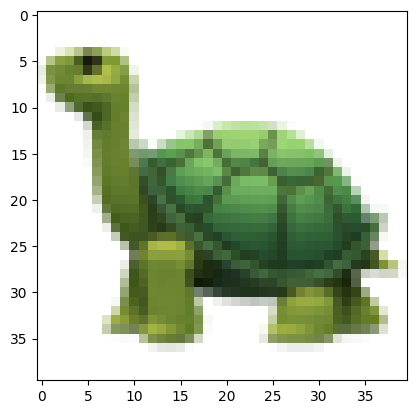

In [15]:
img_tensor_start = load_image(path_start_image)

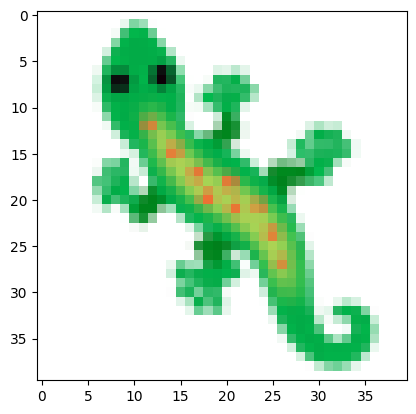

In [16]:
img_tensor = load_image(path)

# Create a starting seed

Create a grid of shape `1, 16, H, W` initialized with zeros, where all elements are set to 0.

Place a single cell in the center of the grid. This central cell should have all channels (except for RGB) set to 1.
The RGB channels of the seed cell are intentionally set to zero to ensure visibility on the white background.

In [27]:
#| export
seed = torch.zeros(1, 16, TARGET_SIZE, TARGET_SIZE).to(def_device)
seed[:, 3:, TARGET_SIZE//2, TARGET_SIZE//2] = 1.0

In [28]:
seed.shape

torch.Size([1, 16, 40, 40])

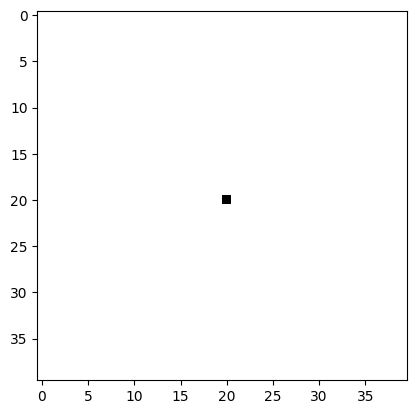

In [9]:
plt.imshow(seed[0, :4].detach().cpu().permute(1, 2, 0))
plt.show()

## start from anm image

In [21]:
img_tensor_start[0].shape

torch.Size([3, 40, 40])

In [22]:
def make_initial_state_from_image(input_img):
    init_state = torch.zeros(1, 16, TARGET_SIZE, TARGET_SIZE).to(def_device)
    init_state[0, :3] = input_img[0]  # since the batch size is 1 we get the only image and get to extract its RGB.
    init_state[0, 3] = 1.0         # we want the NCA to start from a fully initialized sate of the grid (it inspects all cells)
    return init_state


In [23]:
image_seed= make_initial_state_from_image(img_tensor_start)

In [24]:
image_seed.shape


torch.Size([1, 16, 40, 40])

# Training Loop

In [10]:
#|eval: false


# training hyperparameters 
n_epochs = 8000
batch_size = 8

lr = 2e-3
lr_gamma = 0.9999
betas = (0.5, 0.5)

In [11]:
#|eval: false

# initialize the model
ca = CAModel(CHANNEL_N).to(def_device)

In [12]:
#|eval: false


# optimization
import torch.optim as optim

optimizer = torch.optim.Adam(ca.parameters(), lr=lr, betas=betas)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, lr_gamma)

In [ ]:
#|eval: false


# create the input to the network and the target
model_in = seed.repeat(batch_size, 1, 1, 1)
target = img_tensor.repeat(batch_size, 1, 1, 1)

In [14]:
#|eval: false


for i in tqdm(range(n_epochs)):
    optimizer.zero_grad()
    steps = torch.randint(64, 96, (1,)).item()
    res = ca(model_in, steps=steps)

    loss = F.mse_loss(res[:, :4], target) # we only care about the RGBA channels
    if i%500 == 0:
        print(f"Epoch: {i} Loss: {loss.item()}")
    loss.backward()
    optimizer.step()
    scheduler.step()

  0%|          | 0/8000 [00:00<?, ?it/s]

Epoch: 0 Loss: 0.11318175494670868


  6%|▋         | 500/8000 [08:52<2:18:59,  1.11s/it]

Epoch: 500 Loss: 0.024894077330827713


 12%|█▎        | 1000/8000 [17:38<2:08:33,  1.10s/it]

...

 88%|████████▊ | 7000/8000 [2:09:41<19:51,  1.19s/it]

Epoch: 7000 Loss: 0.0007091845036484301


 94%|█████████▍| 7500/8000 [2:19:20<08:59,  1.08s/it]

Epoch: 7500 Loss: 0.0008536372915841639


100%|██████████| 8000/8000 [2:29:00<00:00,  1.12s/it]


Test the training process of the network by generating and displaying an animation.

In [ ]:
#|eval: false


images = ca.grow_animation(seed, 200)
display_animation(images)

As expected, after some time the automato is startig to lose the desired shape.
